# Lab 3: Neural Network

## Objectives:
- To reproduce and extend the workflow using the provided dataset circles_binary_classification.csv. 
- To build, train, evaluate and compare PyTorch ANNs to classify the circular data and report findings.

## Theory:
### Deep Learning:
Deep learning is a subset of machine learning that trains the multilayered artificial neural networks to simulate brain like hierarchical pattern recognition.
- it compromises of input, multiple hidden layers, and then the output,
- it processes data through non linear transformations, 
- during the training process, it uses backpropagation and optimization algorithms to find the values of weights and biases such that the loss is minimum, i.e. the deviation between prediction and actual values is minimum,
- how is differs from the traditional machine learning is that deep learning does not require manual feature extraction and learns directly from the data using neural networks.

### Neural Networks:
Neural networks are the computational models inspired by the human brain. It uses the interconnected layers of nodes called neurons to analyze data, learn patterns and make decisions on the new data.
- it is a fundamental part of deep learning,
- it is comprised of artificial neurons that receive signals, process them, and transmit results through weighted connections,
- Networks train on data, adjusting weight connections to minimize error between predicted and actual outputs.
### Weights and biases:
Weights and biases are the primary learnable parameters in neural networks that determine how input data is transformed into output predictions. 
- weights and biases in a neural network is chosenin such a way that the loss is minimized and the prediction values are close to the actual values.
- weights determine the importance of an imput feature, i.e. higher the weight, the stronger will be the influence of that feature on the output,
- biases are the additional parameters allowing to shift the activation function to better fit the data.

> Each neuron can have multiple weights but only single bias.

> $Y =(\sum_{i=0}^n w_i x_i) + b$

Here,
> $w$ stands for the weight of each connection to the neuron

> $x$ stands for the value of the connected neuron from the previous value

> $b$ stands for the bias at each layer, this is a constant

> $n$ is the number of connections

> $Y$ is the output of the current neuron

### Layers:
Neural networks are organized into multiple layers, each performing a specific transformation on the data. The input data flows through these layers sequentially until it reaches the output layer, where the final result is produced.

#### Input Layer
The input layer serves as the entry point for data into the neural network. It receives the raw input features and passes them to the subsequent layers. The number of neurons in this layer corresponds directly to the number of input features - for instance, an image with 28x28 pixels (784 total pixels) would require 784 neurons in the input layer.

#### Output Layer
The output layer is the final layer of the network where results are retrieved. After data has been processed through all preceding layers, the output layer produces the network's predictions or classifications.

#### Hidden Layers
All layers between the input and output layers are called hidden layers. They are termed "hidden" because their internal computations are not directly observable from outside the network. A neural network typically contains at least one hidden layer, though complex models may have many more. Generally, increased model complexity correlates with a greater number of hidden layers.

#### Neurons
Each layer consists of units called neurons. Every neuron is responsible for holding, generating, and passing a single numeric value. The number of neurons varies by layer type:
- **Input layer**: matches the number of input features
- **Output layer**: matches the number of output classes or values
- **Hidden layers**: determined by the network architect based on the problem complexity
#### Connected Layers
Neurons in one layer connect to neurons in subsequent layers through various connection patterns. When every neuron in one layer connects to every neuron in the next layer, this is called a dense (or fully connected) layer. Other connection architectures exist and are used depending on the specific application and data type.

## Additional things:
### 1. ReLU (Rectified Linear Unit) Activation Function

The Rectified Linear Unit (ReLU) is a widely used activation function in neural networks. It introduces non-linearity into the model, allowing the network to learn complex patterns in data.

$$
f(x) = \max(0, x)
$$

- If the input value is positive, the output equals the input.  
- If the input value is negative, the output is zero.  

Thus, ReLU sets all negative values to zero and keeps positive values unchanged.

- Computationally simple and efficient  
- Helps mitigate the vanishing gradient problem  
- Enables faster training of deep neural networks  

A potential issue with ReLU is the **dying ReLU problem**, where neurons output zero for all inputs if they consistently receive negative values, preventing further learning.


### 2. Stochastic Gradient Descent (SGD)
Stochastic Gradient Descent (SGD) is an optimization algorithm used to minimize the loss function of a neural network by iteratively updating model weights.

> SGD updates weights by moving them in the direction opposite to the gradient of the loss function. This process gradually reduces prediction error.

#### Update Rule
$$
w = w - \eta \nabla L
$$
Where:
- $w$ = model weights  
- $\eta$ = learning rate  
- $\nabla L$ = gradient of the loss function  

- Updates parameters using one sample or a small batch at a time  
- Faster computation compared to full-batch gradient descent  
- Introduces noise in updates, which can help escape local minima  

But,
- Can be slow to converge  
- May oscillate near the minimum due to noisy updates  


### 3. Adam (Adaptive Moment Estimation) Optimizer

Adam is an advanced optimization algorithm that combines the ideas of momentum and adaptive learning rates to improve training efficiency.

Adam maintains:
- An exponentially decaying average of past gradients (momentum)  
- An exponentially decaying average of squared gradients (adaptive learning rate)  

These estimates help the optimizer adjust learning rates for each parameter individually.

- Faster convergence  
- Requires minimal hyperparameter tuning  
- Effective for large and complex neural networks  
- Works well with sparse gradients  

## Tasks:
1 . Data retrieval & inspection

In [4]:
# Import libraries
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Load data
data = pd.read_csv('circles_binary_classification.csv')
print("First 5 rows:")
print(data.head())
print("\nDataset shape:", data.shape)
print("\nStatistical summary:")
print(data.describe())
print("\nData types:")
print(data.dtypes)
print("\nMissing values:")
print(data.isnull().sum())

First 5 rows:
         X1        X2  label
0  0.754246  0.231481      1
1 -0.756159  0.153259      1
2 -0.815392  0.173282      1
3 -0.393731  0.692883      1
4  0.442208 -0.896723      0

Dataset shape: (1000, 3)

Statistical summary:
                X1           X2       label
count  1000.000000  1000.000000  1000.00000
mean     -0.000448    -0.000804     0.50000
std       0.639837     0.641156     0.50025
min      -1.059502    -1.067768     0.00000
25%      -0.619251    -0.612176     0.00000
50%       0.008762    -0.003949     0.50000
75%       0.621933     0.624822     1.00000
max       1.033712     1.036004     1.00000

Data types:
X1       float64
X2       float64
label      int64
dtype: object

Missing values:
X1       0
X2       0
label    0
dtype: int64


2. Data cleaning & feature design

In [5]:
# Data cleaning - check for issues
print("Checking for duplicates:", data.duplicated().sum())
print("Unique labels:", data['label'].unique())

# No missing values, no duplicates - data is clean

# Feature design: Create X and y
X = data[['X1', 'X2']].values
y = data['label'].values

print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("X dtype:", X.dtype)
print("y dtype:", y.dtype)

# Convert to PyTorch tensors with correct dtypes
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # Shape: (n, 1) for BCEWithLogitsLoss

print("\nTensor shapes:")
print("X_tensor:", X_tensor.shape)
print("y_tensor:", y_tensor.shape)

Checking for duplicates: 0
Unique labels: [1 0]

X shape: (1000, 2)
y shape: (1000,)
X dtype: float64
y dtype: int64

Tensor shapes:
X_tensor: torch.Size([1000, 2])
y_tensor: torch.Size([1000, 1])


3. Visualize data

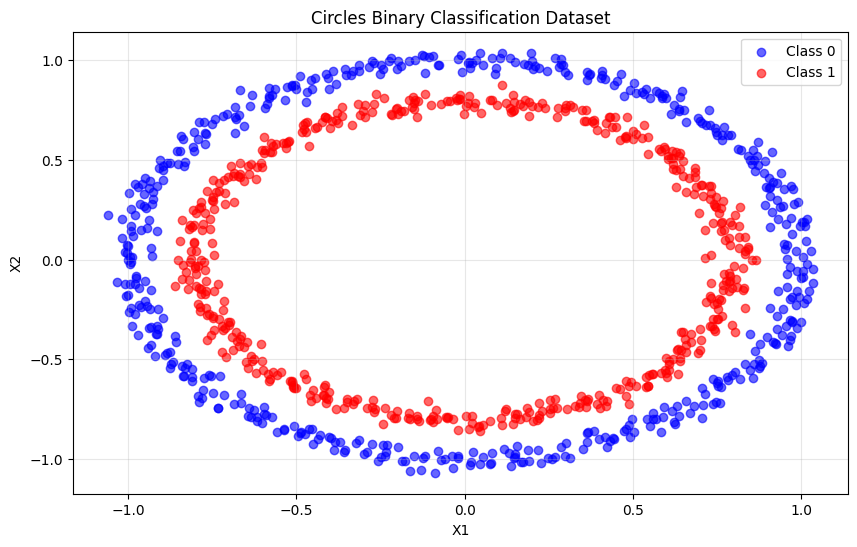

Class distribution:
Class 0: 500 samples
Class 1: 500 samples


In [6]:
# Scatter plot X1 vs X2 colored by label
plt.figure(figsize=(10, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='blue', label='Class 0', alpha=0.6)
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red', label='Class 1', alpha=0.6)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Circles Binary Classification Dataset')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Class distribution:")
print(f"Class 0: {(y == 0).sum()} samples")
print(f"Class 1: {(y == 1).sum()} samples")

4. Train/Test Split

In [7]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("\nTraining X shape:", X_train.shape)
print("Training y shape:", y_train.shape)
print("Test X shape:", X_test.shape)
print("Test y shape:", y_test.shape)

Training set size: 800
Test set size: 200

Training X shape: torch.Size([800, 2])
Training y shape: torch.Size([800, 1])
Test X shape: torch.Size([200, 2])
Test y shape: torch.Size([200, 1])


5. Device & dtype setup

In [8]:
# Device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Move tensors to device
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

print(f"X_train device: {X_train.device}")
print(f"y_train device: {y_train.device}")

Using device: cpu
X_train device: cpu
y_train device: cpu


6. Model definitions

We will implement three different model architectures:
- **ModelV0**: Simple linear model (2 → 5 → 1, no activation)
- **ModelV1**: Deeper linear model (2 → 15 → 15 → 1, no activation)
- **ModelV2**: Deep model with ReLU activation (2 → 64 → 64 → 10 → 1)

In [9]:
# ModelV0: 2 → 5 → 1 (no activation) - Simple baseline
class ModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 5)
        self.layer2 = nn.Linear(5, 1)
    
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        return x

# ModelV1: 2 → 15 → 15 → 1 (no activation) - Deeper linear model
class ModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 15)
        self.layer2 = nn.Linear(15, 15)
        self.layer3 = nn.Linear(15, 1)
    
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return x

# ModelV2: 2 → 64 → 64 → 10 → 1 with ReLU between layers
class ModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 64)
        self.layer2 = nn.Linear(64, 64)
        self.layer3 = nn.Linear(64, 10)
        self.layer4 = nn.Linear(10, 1)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.relu(self.layer3(x))
        x = self.layer4(x)
        return x

print("Models defined successfully!")
print("\nModelV0 architecture:")
print(ModelV0())
print("\nModelV1 architecture:")
print(ModelV1())
print("\nModelV2 architecture:")
print(ModelV2())

Models defined successfully!

ModelV0 architecture:
ModelV0(
  (layer1): Linear(in_features=2, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=1, bias=True)
)

ModelV1 architecture:
ModelV1(
  (layer1): Linear(in_features=2, out_features=15, bias=True)
  (layer2): Linear(in_features=15, out_features=15, bias=True)
  (layer3): Linear(in_features=15, out_features=1, bias=True)
)

ModelV2 architecture:
ModelV2(
  (layer1): Linear(in_features=2, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=64, bias=True)
  (layer3): Linear(in_features=64, out_features=10, bias=True)
  (layer4): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


7. Loss, optimizer, and helper functions

In [10]:
# Accuracy function
def accuracy_fn(y_true, y_pred_logits):
    """Calculate accuracy from logits"""
    y_pred_probs = torch.sigmoid(y_pred_logits)
    y_pred_labels = torch.round(y_pred_probs)
    correct = (y_pred_labels == y_true).sum().item()
    return (correct / len(y_true)) * 100

# Decision boundary plotting function
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    """Plot decision boundary for 2D data"""
    model.eval()
    
    # Create a mesh grid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # Make predictions on mesh
    X_grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32).to(device)
    with torch.no_grad():
        Z = torch.sigmoid(model(X_grid)).cpu().numpy()
    Z = Z.reshape(xx.shape)
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
    
    # Plot data points
    X_np = X.cpu().numpy() if hasattr(X, 'cpu') else X
    y_np = y.cpu().numpy().squeeze() if hasattr(y, 'cpu') else y.squeeze()
    plt.scatter(X_np[y_np == 0, 0], X_np[y_np == 0, 1], c='blue', label='Class 0', edgecolors='k', alpha=0.7)
    plt.scatter(X_np[y_np == 1, 0], X_np[y_np == 1, 1], c='red', label='Class 1', edgecolors='k', alpha=0.7)
    
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title(title)
    plt.legend()
    plt.show()

# Training and testing loop function
def train_and_test_loop(model, X_train, y_train, X_test, y_test, 
                        optimizer, loss_fn, epochs, print_every=10):
    """Train and evaluate model, returning loss and accuracy history"""
    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        
        # Forward pass
        y_train_logits = model(X_train)
        train_loss = loss_fn(y_train_logits, y_train)
        train_acc = accuracy_fn(y_train, y_train_logits)
        
        # Backward pass
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        
        # Evaluation phase
        model.eval()
        with torch.no_grad():
            y_test_logits = model(X_test)
            test_loss = loss_fn(y_test_logits, y_test)
            test_acc = accuracy_fn(y_test, y_test_logits)
        
        # Record history
        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())
        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)
        
        # Print progress
        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch+1:4d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
                  f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")
    
    return {
        'train_losses': train_losses,
        'test_losses': test_losses,
        'train_accuracies': train_accuracies,
        'test_accuracies': test_accuracies
    }

# Plot training curves function
def plot_training_curves(history, model_name):
    """Plot loss and accuracy curves"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss curves
    axes[0].plot(history['train_losses'], label='Train Loss')
    axes[0].plot(history['test_losses'], label='Test Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{model_name} - Loss Curves')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy curves
    axes[1].plot(history['train_accuracies'], label='Train Accuracy')
    axes[1].plot(history['test_accuracies'], label='Test Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title(f'{model_name} - Accuracy Curves')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("Helper functions defined successfully!")

Helper functions defined successfully!


8. Training ModelV0 (Baseline - No Activation)

ModelV0 Architecture:
ModelV0(
  (layer1): Linear(in_features=2, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=1, bias=True)
)

--- Untrained Model Predictions ---
Actual: [1.0, 0.0, 1.0, 0.0, 1.0]
Predicted: [0.0, 0.0, 0.0, 0.0, 0.0]
Probabilities: [0.46831321716308594, 0.47583621740341187, 0.45243528485298157, 0.4728095531463623, 0.45842447876930237]


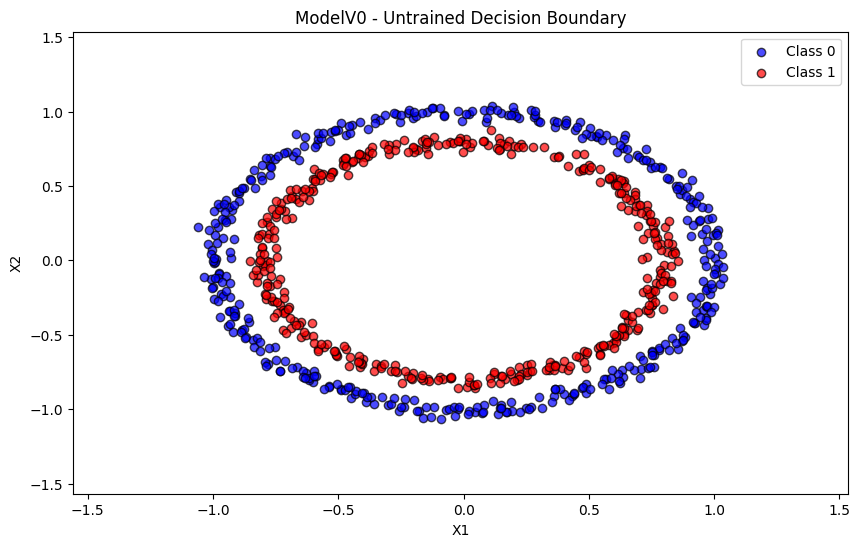

In [11]:
# Reset random seed
torch.manual_seed(42)

# Initialize ModelV0
model_v0 = ModelV0().to(device)
print("ModelV0 Architecture:")
print(model_v0)

# Loss function and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer_v0 = torch.optim.SGD(model_v0.parameters(), lr=0.1)

# Show untrained predictions
print("\n--- Untrained Model Predictions ---")
model_v0.eval()
with torch.no_grad():
    y_test_logits = model_v0(X_test[:5])
    y_test_probs = torch.sigmoid(y_test_logits)
    y_test_preds = torch.round(y_test_probs)
    print(f"Actual: {y_test[:5].squeeze().tolist()}")
    print(f"Predicted: {y_test_preds.squeeze().tolist()}")
    print(f"Probabilities: {y_test_probs.squeeze().tolist()}")

# Plot untrained decision boundary
plot_decision_boundary(model_v0, X_train, y_train, title="ModelV0 - Untrained Decision Boundary")

In [12]:
# Train ModelV0
print("Training ModelV0 for 100 epochs...")
print("=" * 80)

history_v0 = train_and_test_loop(
    model=model_v0,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    optimizer=optimizer_v0,
    loss_fn=loss_fn,
    epochs=100,
    print_every=10
)

print("=" * 80)
print(f"Final Train Accuracy: {history_v0['train_accuracies'][-1]:.2f}%")
print(f"Final Test Accuracy: {history_v0['test_accuracies'][-1]:.2f}%")

Training ModelV0 for 100 epochs...
Epoch   10 | Train Loss: 0.6941 | Train Acc: 50.00% | Test Loss: 0.6962 | Test Acc: 50.00%
Epoch   20 | Train Loss: 0.6935 | Train Acc: 46.00% | Test Loss: 0.6959 | Test Acc: 47.00%
Epoch   30 | Train Loss: 0.6932 | Train Acc: 49.25% | Test Loss: 0.6958 | Test Acc: 47.00%
Epoch   40 | Train Loss: 0.6931 | Train Acc: 49.12% | Test Loss: 0.6957 | Test Acc: 46.50%
Epoch   50 | Train Loss: 0.6931 | Train Acc: 50.12% | Test Loss: 0.6957 | Test Acc: 46.50%
Epoch   60 | Train Loss: 0.6931 | Train Acc: 50.25% | Test Loss: 0.6956 | Test Acc: 46.50%
Epoch   70 | Train Loss: 0.6930 | Train Acc: 50.25% | Test Loss: 0.6956 | Test Acc: 46.50%
Epoch   80 | Train Loss: 0.6930 | Train Acc: 50.75% | Test Loss: 0.6955 | Test Acc: 46.50%
Epoch   90 | Train Loss: 0.6930 | Train Acc: 50.38% | Test Loss: 0.6955 | Test Acc: 46.50%
Epoch  100 | Train Loss: 0.6930 | Train Acc: 50.50% | Test Loss: 0.6954 | Test Acc: 46.50%
Final Train Accuracy: 50.50%
Final Test Accuracy: 46.50

--- Trained Model Predictions ---
Actual: [1.0, 0.0, 1.0, 0.0, 1.0]
Predicted: [1.0, 1.0, 0.0, 1.0, 0.0]
Probabilities: [0.5062035322189331, 0.5155041813850403, 0.4855678975582123, 0.5120342373847961, 0.4915219247341156]


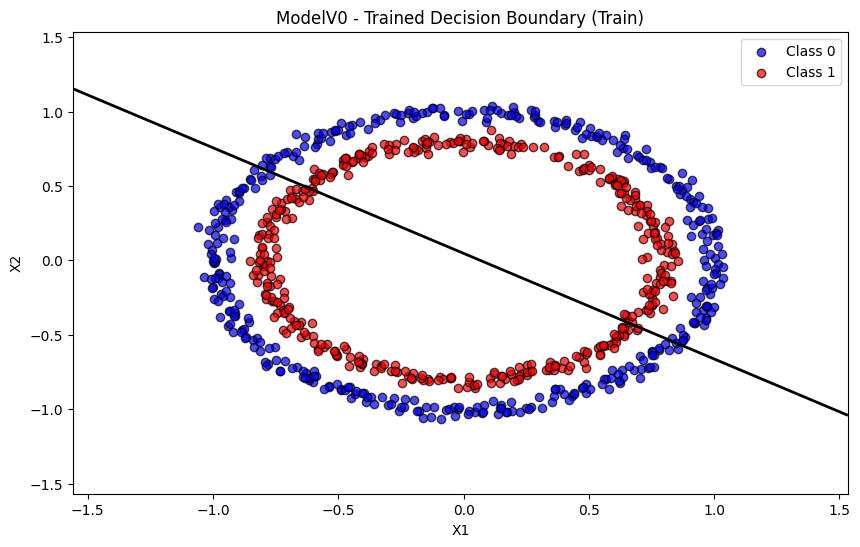

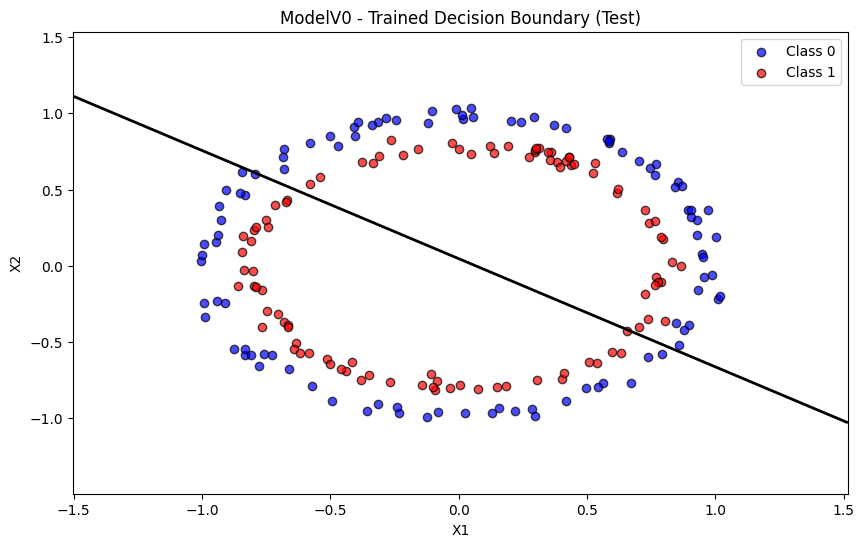

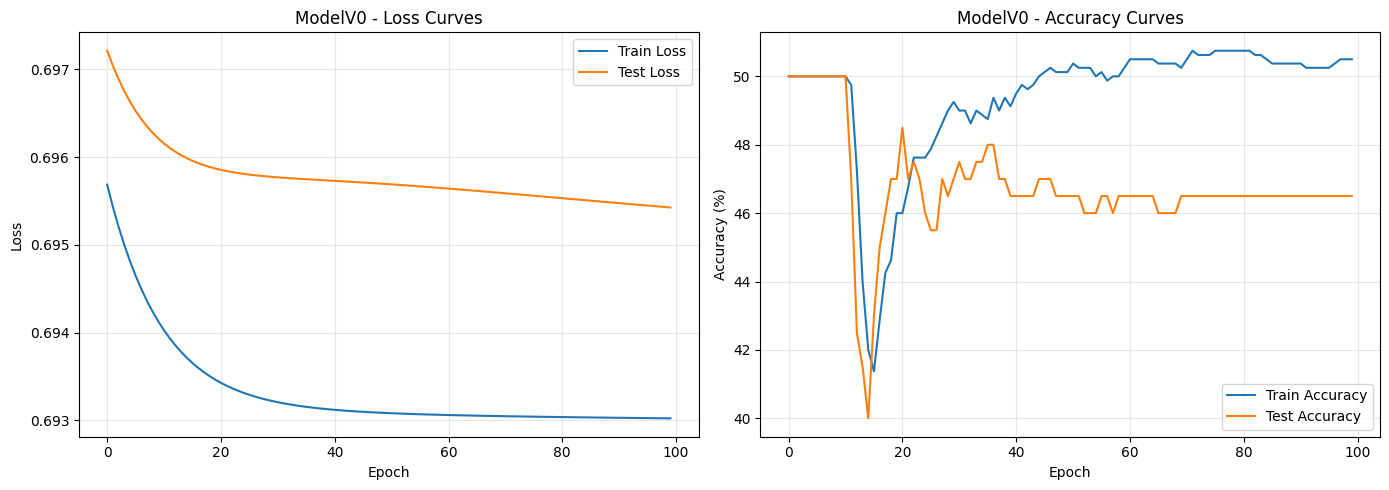

In [13]:
# ModelV0 Evaluation - Trained predictions and plots
print("--- Trained Model Predictions ---")
model_v0.eval()
with torch.no_grad():
    y_test_logits = model_v0(X_test[:5])
    y_test_probs = torch.sigmoid(y_test_logits)
    y_test_preds = torch.round(y_test_probs)
    print(f"Actual: {y_test[:5].squeeze().tolist()}")
    print(f"Predicted: {y_test_preds.squeeze().tolist()}")
    print(f"Probabilities: {y_test_probs.squeeze().tolist()}")

# Plot trained decision boundary
plot_decision_boundary(model_v0, X_train, y_train, title="ModelV0 - Trained Decision Boundary (Train)")
plot_decision_boundary(model_v0, X_test, y_test, title="ModelV0 - Trained Decision Boundary (Test)")

# Plot training curves
plot_training_curves(history_v0, "ModelV0")

9. Training ModelV1 (Deeper Linear - No Activation)

ModelV1 Architecture:
ModelV1(
  (layer1): Linear(in_features=2, out_features=15, bias=True)
  (layer2): Linear(in_features=15, out_features=15, bias=True)
  (layer3): Linear(in_features=15, out_features=1, bias=True)
)

--- Untrained Model Predictions ---
Actual: [1.0, 0.0, 1.0, 0.0, 1.0]
Predicted: [1.0, 1.0, 1.0, 1.0, 1.0]


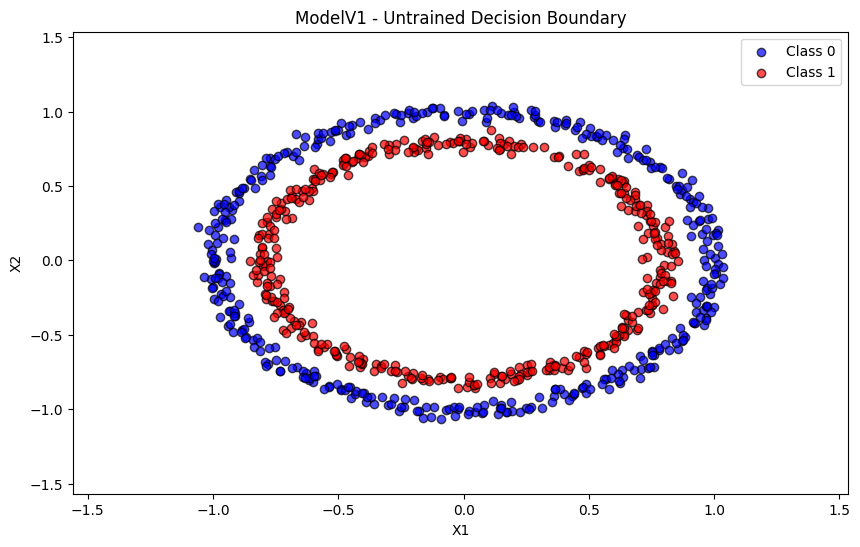

In [14]:
# Reset random seed and reinitialize model
torch.manual_seed(42)

# Initialize ModelV1
model_v1 = ModelV1().to(device)
print("ModelV1 Architecture:")
print(model_v1)

# Loss function and optimizer (reinitialize)
loss_fn = nn.BCEWithLogitsLoss()
optimizer_v1 = torch.optim.SGD(model_v1.parameters(), lr=0.1)

# Show untrained predictions
print("\n--- Untrained Model Predictions ---")
model_v1.eval()
with torch.no_grad():
    y_test_logits = model_v1(X_test[:5])
    y_test_probs = torch.sigmoid(y_test_logits)
    y_test_preds = torch.round(y_test_probs)
    print(f"Actual: {y_test[:5].squeeze().tolist()}")
    print(f"Predicted: {y_test_preds.squeeze().tolist()}")

# Plot untrained decision boundary
plot_decision_boundary(model_v1, X_train, y_train, title="ModelV1 - Untrained Decision Boundary")

In [15]:
# Train ModelV1
print("Training ModelV1 for 1000 epochs...")
print("=" * 80)

history_v1 = train_and_test_loop(
    model=model_v1,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    optimizer=optimizer_v1,
    loss_fn=loss_fn,
    epochs=1000,
    print_every=100
)

print("=" * 80)
print(f"Final Train Accuracy: {history_v1['train_accuracies'][-1]:.2f}%")
print(f"Final Test Accuracy: {history_v1['test_accuracies'][-1]:.2f}%")

Training ModelV1 for 1000 epochs...
Epoch  100 | Train Loss: 0.6930 | Train Acc: 51.25% | Test Loss: 0.6945 | Test Acc: 46.50%
Epoch  200 | Train Loss: 0.6930 | Train Acc: 51.62% | Test Loss: 0.6947 | Test Acc: 45.00%
Epoch  300 | Train Loss: 0.6930 | Train Acc: 51.12% | Test Loss: 0.6947 | Test Acc: 46.00%
Epoch  400 | Train Loss: 0.6930 | Train Acc: 51.00% | Test Loss: 0.6947 | Test Acc: 46.00%
Epoch  500 | Train Loss: 0.6930 | Train Acc: 51.00% | Test Loss: 0.6947 | Test Acc: 46.00%
Epoch  600 | Train Loss: 0.6930 | Train Acc: 51.00% | Test Loss: 0.6947 | Test Acc: 46.00%
Epoch  700 | Train Loss: 0.6930 | Train Acc: 51.00% | Test Loss: 0.6947 | Test Acc: 46.00%
Epoch  800 | Train Loss: 0.6930 | Train Acc: 51.00% | Test Loss: 0.6947 | Test Acc: 46.00%
Epoch  900 | Train Loss: 0.6930 | Train Acc: 51.00% | Test Loss: 0.6947 | Test Acc: 46.00%
Epoch 1000 | Train Loss: 0.6930 | Train Acc: 51.00% | Test Loss: 0.6947 | Test Acc: 46.00%
Final Train Accuracy: 51.00%
Final Test Accuracy: 46.0

--- Trained Model Predictions ---
Actual: [1.0, 0.0, 1.0, 0.0, 1.0]
Predicted: [1.0, 1.0, 0.0, 1.0, 0.0]
Probabilities: [0.5070061683654785, 0.5129397511482239, 0.4919765889644623, 0.5112614035606384, 0.4928175210952759]


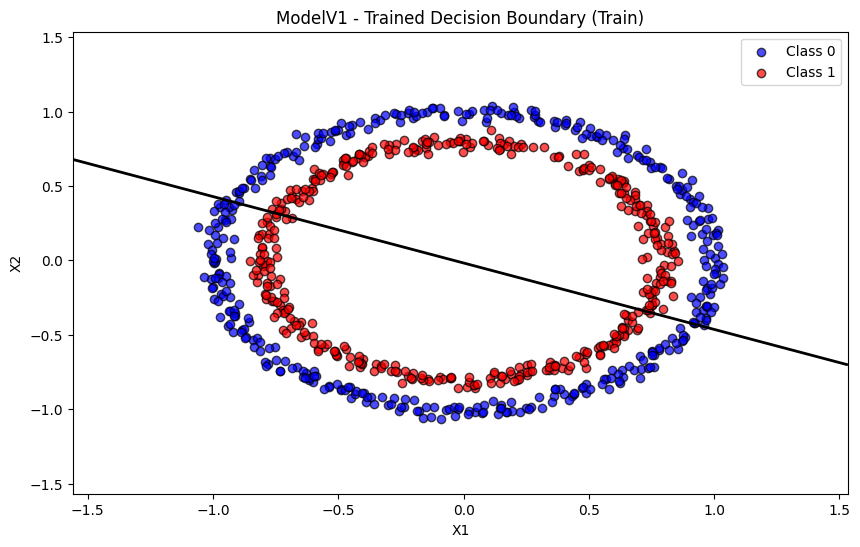

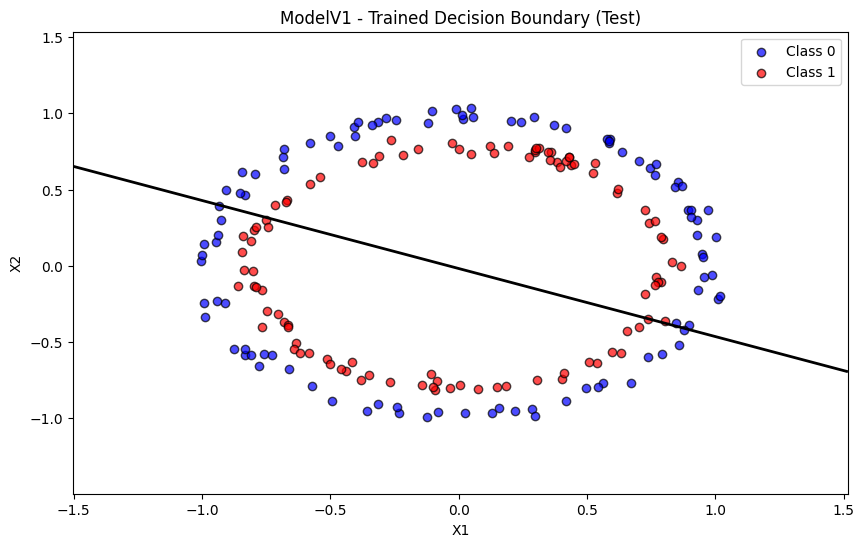

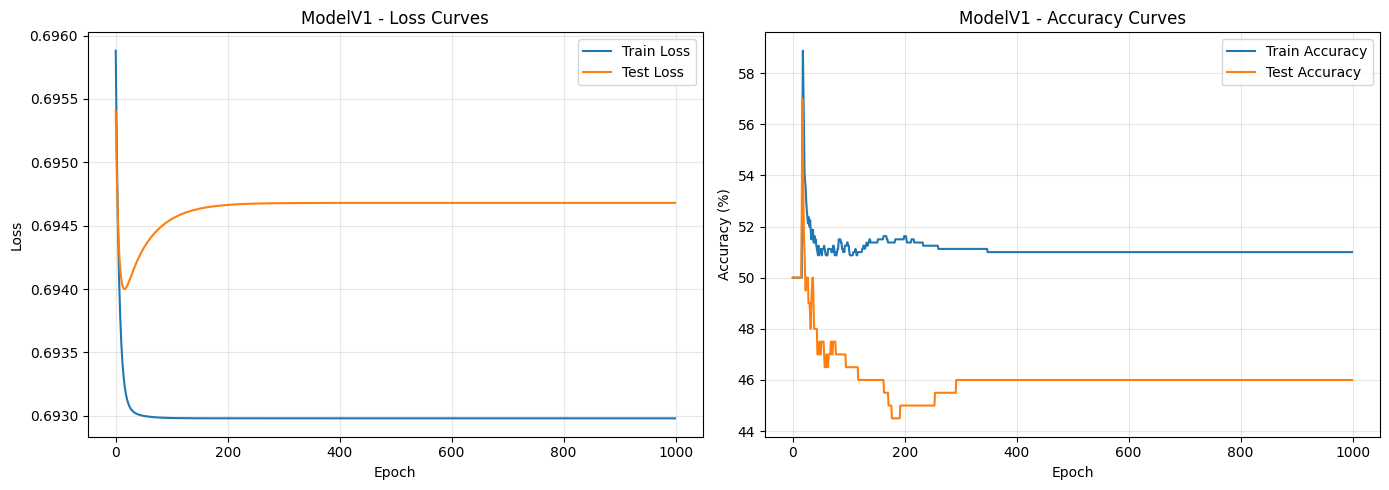

In [16]:
# ModelV1 Evaluation - Trained predictions and plots
print("--- Trained Model Predictions ---")
model_v1.eval()
with torch.no_grad():
    y_test_logits = model_v1(X_test[:5])
    y_test_probs = torch.sigmoid(y_test_logits)
    y_test_preds = torch.round(y_test_probs)
    print(f"Actual: {y_test[:5].squeeze().tolist()}")
    print(f"Predicted: {y_test_preds.squeeze().tolist()}")
    print(f"Probabilities: {y_test_probs.squeeze().tolist()}")

# Plot trained decision boundary
plot_decision_boundary(model_v1, X_train, y_train, title="ModelV1 - Trained Decision Boundary (Train)")
plot_decision_boundary(model_v1, X_test, y_test, title="ModelV1 - Trained Decision Boundary (Test)")

# Plot training curves
plot_training_curves(history_v1, "ModelV1")

10. Training ModelV2 (With ReLU Activation)

ModelV2 Architecture:
ModelV2(
  (layer1): Linear(in_features=2, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=64, bias=True)
  (layer3): Linear(in_features=64, out_features=10, bias=True)
  (layer4): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

--- Untrained Model Predictions ---
Actual: [1.0, 0.0, 1.0, 0.0, 1.0]
Predicted: [1.0, 1.0, 1.0, 1.0, 1.0]


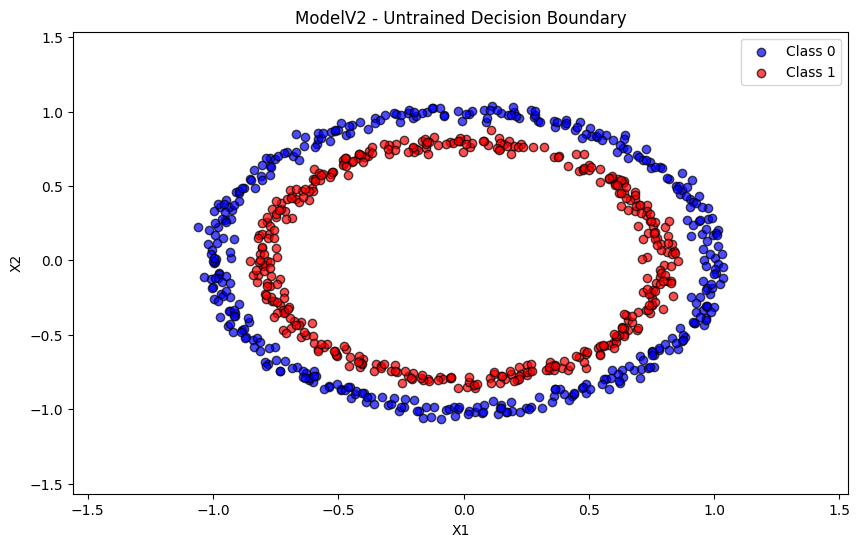

In [17]:
# Reset random seed and reinitialize model
torch.manual_seed(42)

# Initialize ModelV2
model_v2 = ModelV2().to(device)
print("ModelV2 Architecture:")
print(model_v2)

# Loss function and optimizer (reinitialize)
loss_fn = nn.BCEWithLogitsLoss()
optimizer_v2 = torch.optim.SGD(model_v2.parameters(), lr=0.1)

# Show untrained predictions
print("\n--- Untrained Model Predictions ---")
model_v2.eval()
with torch.no_grad():
    y_test_logits = model_v2(X_test[:5])
    y_test_probs = torch.sigmoid(y_test_logits)
    y_test_preds = torch.round(y_test_probs)
    print(f"Actual: {y_test[:5].squeeze().tolist()}")
    print(f"Predicted: {y_test_preds.squeeze().tolist()}")

# Plot untrained decision boundary
plot_decision_boundary(model_v2, X_train, y_train, title="ModelV2 - Untrained Decision Boundary")

In [18]:
# Train ModelV2
print("Training ModelV2 for 1000 epochs...")
print("=" * 80)

history_v2 = train_and_test_loop(
    model=model_v2,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    optimizer=optimizer_v2,
    loss_fn=loss_fn,
    epochs=1000,
    print_every=100
)

print("=" * 80)
print(f"Final Train Accuracy: {history_v2['train_accuracies'][-1]:.2f}%")
print(f"Final Test Accuracy: {history_v2['test_accuracies'][-1]:.2f}%")

Training ModelV2 for 1000 epochs...


Epoch  100 | Train Loss: 0.6882 | Train Acc: 56.75% | Test Loss: 0.6897 | Test Acc: 53.50%
Epoch  200 | Train Loss: 0.6803 | Train Acc: 67.88% | Test Loss: 0.6842 | Test Acc: 60.50%
Epoch  300 | Train Loss: 0.6592 | Train Acc: 80.50% | Test Loss: 0.6681 | Test Acc: 72.50%
Epoch  400 | Train Loss: 0.5669 | Train Acc: 97.88% | Test Loss: 0.5873 | Test Acc: 97.00%
Epoch  500 | Train Loss: 0.4721 | Train Acc: 63.25% | Test Loss: 0.5175 | Test Acc: 60.00%
Epoch  600 | Train Loss: 0.3545 | Train Acc: 78.38% | Test Loss: 0.4069 | Test Acc: 74.00%
Epoch  700 | Train Loss: 0.0522 | Train Acc: 100.00% | Test Loss: 0.0801 | Test Acc: 100.00%
Epoch  800 | Train Loss: 0.0225 | Train Acc: 100.00% | Test Loss: 0.0420 | Test Acc: 100.00%
Epoch  900 | Train Loss: 0.0135 | Train Acc: 100.00% | Test Loss: 0.0289 | Test Acc: 100.00%
Epoch 1000 | Train Loss: 0.0094 | Train Acc: 100.00% | Test Loss: 0.0223 | Test Acc: 100.00%
Final Train Accuracy: 100.00%
Final Test Accuracy: 100.00%


--- Trained Model Predictions ---
Actual: [1.0, 0.0, 1.0, 0.0, 1.0]
Predicted: [1.0, 0.0, 1.0, 0.0, 1.0]
Probabilities: [0.9985077977180481, 0.03379584848880768, 0.998852014541626, 0.0012412298237904906, 0.9631882905960083]


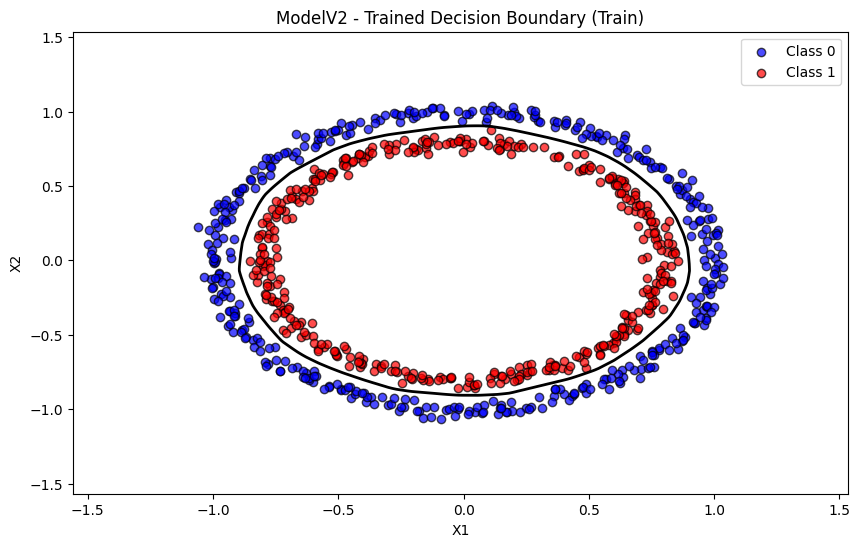

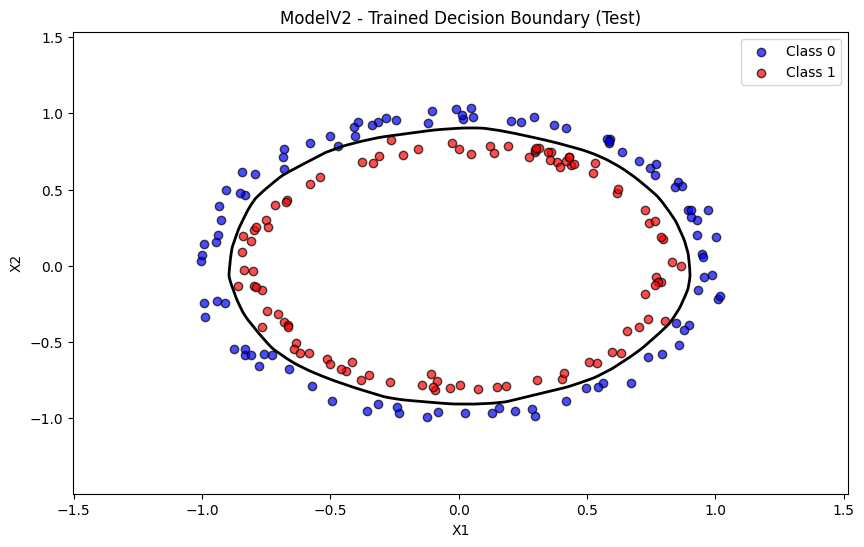

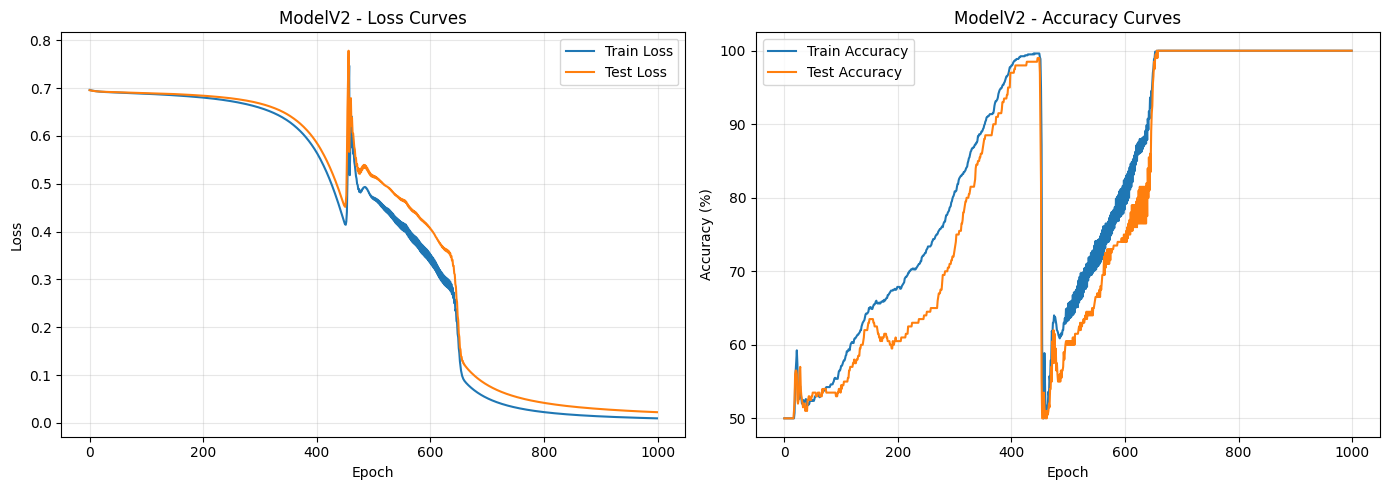

In [19]:
# ModelV2 Evaluation - Trained predictions and plots
print("--- Trained Model Predictions ---")
model_v2.eval()
with torch.no_grad():
    y_test_logits = model_v2(X_test[:5])
    y_test_probs = torch.sigmoid(y_test_logits)
    y_test_preds = torch.round(y_test_probs)
    print(f"Actual: {y_test[:5].squeeze().tolist()}")
    print(f"Predicted: {y_test_preds.squeeze().tolist()}")
    print(f"Probabilities: {y_test_probs.squeeze().tolist()}")

# Plot trained decision boundary
plot_decision_boundary(model_v2, X_train, y_train, title="ModelV2 - Trained Decision Boundary (Train)")
plot_decision_boundary(model_v2, X_test, y_test, title="ModelV2 - Trained Decision Boundary (Test)")

# Plot training curves
plot_training_curves(history_v2, "ModelV2")

11. Model Comparison

MODEL COMPARISON SUMMARY
  Model              Architecture  Epochs  Final Train Acc (%)  Final Test Acc (%)  Final Train Loss  Final Test Loss
ModelV0     2→5→1 (no activation)     100                 50.5                46.5          0.693023         0.695426
ModelV1 2→15→15→1 (no activation)    1000                 51.0                46.0          0.692980         0.694680
ModelV2       2→64→64→10→1 (ReLU)    1000                100.0               100.0          0.009397         0.022280


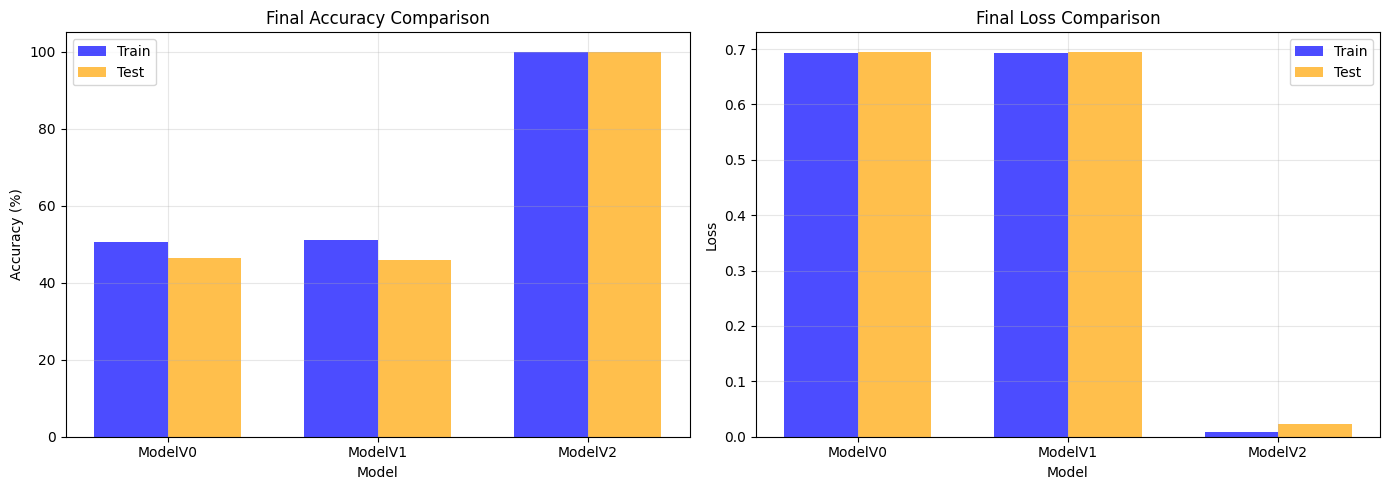

In [20]:
# Compare all models
print("=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)

results = {
    'Model': ['ModelV0', 'ModelV1', 'ModelV2'],
    'Architecture': ['2→5→1 (no activation)', '2→15→15→1 (no activation)', '2→64→64→10→1 (ReLU)'],
    'Epochs': [100, 1000, 1000],
    'Final Train Acc (%)': [
        history_v0['train_accuracies'][-1],
        history_v1['train_accuracies'][-1],
        history_v2['train_accuracies'][-1]
    ],
    'Final Test Acc (%)': [
        history_v0['test_accuracies'][-1],
        history_v1['test_accuracies'][-1],
        history_v2['test_accuracies'][-1]
    ],
    'Final Train Loss': [
        history_v0['train_losses'][-1],
        history_v1['train_losses'][-1],
        history_v2['train_losses'][-1]
    ],
    'Final Test Loss': [
        history_v0['test_losses'][-1],
        history_v1['test_losses'][-1],
        history_v2['test_losses'][-1]
    ]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
models = ['ModelV0', 'ModelV1', 'ModelV2']
train_accs = [history_v0['train_accuracies'][-1], history_v1['train_accuracies'][-1], history_v2['train_accuracies'][-1]]
test_accs = [history_v0['test_accuracies'][-1], history_v1['test_accuracies'][-1], history_v2['test_accuracies'][-1]]

x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, train_accs, width, label='Train', color='blue', alpha=0.7)
axes[0].bar(x + width/2, test_accs, width, label='Test', color='orange', alpha=0.7)
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Final Accuracy Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].set_ylim(0, 105)
axes[0].grid(True, alpha=0.3)

# Loss comparison
train_losses = [history_v0['train_losses'][-1], history_v1['train_losses'][-1], history_v2['train_losses'][-1]]
test_losses = [history_v0['test_losses'][-1], history_v1['test_losses'][-1], history_v2['test_losses'][-1]]

axes[1].bar(x - width/2, train_losses, width, label='Train', color='blue', alpha=0.7)
axes[1].bar(x + width/2, test_losses, width, label='Test', color='orange', alpha=0.7)
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Loss')
axes[1].set_title('Final Loss Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

12.  Adam vs SGD Comparison

In [21]:
# Compare SGD vs Adam optimizer on ModelV2
print("Comparing SGD vs Adam on ModelV2")
print("=" * 80)

# Train with SGD (already done as model_v2, but let's retrain for fair comparison)
torch.manual_seed(42)
model_sgd = ModelV2().to(device)
optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.1)
print("Training ModelV2 with SGD...")
history_sgd = train_and_test_loop(
    model=model_sgd,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    optimizer=optimizer_sgd,
    loss_fn=loss_fn,
    epochs=500,
    print_every=100
)

# Train with Adam
torch.manual_seed(42)
model_adam = ModelV2().to(device)
optimizer_adam = torch.optim.Adam(model_adam.parameters(), lr=0.01)
print("\nTraining ModelV2 with Adam...")
history_adam = train_and_test_loop(
    model=model_adam,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    optimizer=optimizer_adam,
    loss_fn=loss_fn,
    epochs=500,
    print_every=100
)

print("=" * 80)

Comparing SGD vs Adam on ModelV2
Training ModelV2 with SGD...
Epoch  100 | Train Loss: 0.6882 | Train Acc: 56.75% | Test Loss: 0.6897 | Test Acc: 53.50%
Epoch  200 | Train Loss: 0.6803 | Train Acc: 67.88% | Test Loss: 0.6842 | Test Acc: 60.50%
Epoch  300 | Train Loss: 0.6592 | Train Acc: 80.50% | Test Loss: 0.6681 | Test Acc: 72.50%
Epoch  400 | Train Loss: 0.5669 | Train Acc: 97.88% | Test Loss: 0.5873 | Test Acc: 97.00%
Epoch  500 | Train Loss: 0.4721 | Train Acc: 63.25% | Test Loss: 0.5175 | Test Acc: 60.00%

Training ModelV2 with Adam...
Epoch  100 | Train Loss: 0.0007 | Train Acc: 100.00% | Test Loss: 0.0044 | Test Acc: 100.00%
Epoch  200 | Train Loss: 0.0003 | Train Acc: 100.00% | Test Loss: 0.0029 | Test Acc: 100.00%
Epoch  300 | Train Loss: 0.0002 | Train Acc: 100.00% | Test Loss: 0.0022 | Test Acc: 100.00%
Epoch  400 | Train Loss: 0.0001 | Train Acc: 100.00% | Test Loss: 0.0017 | Test Acc: 100.00%
Epoch  500 | Train Loss: 0.0001 | Train Acc: 100.00% | Test Loss: 0.0015 | Test 

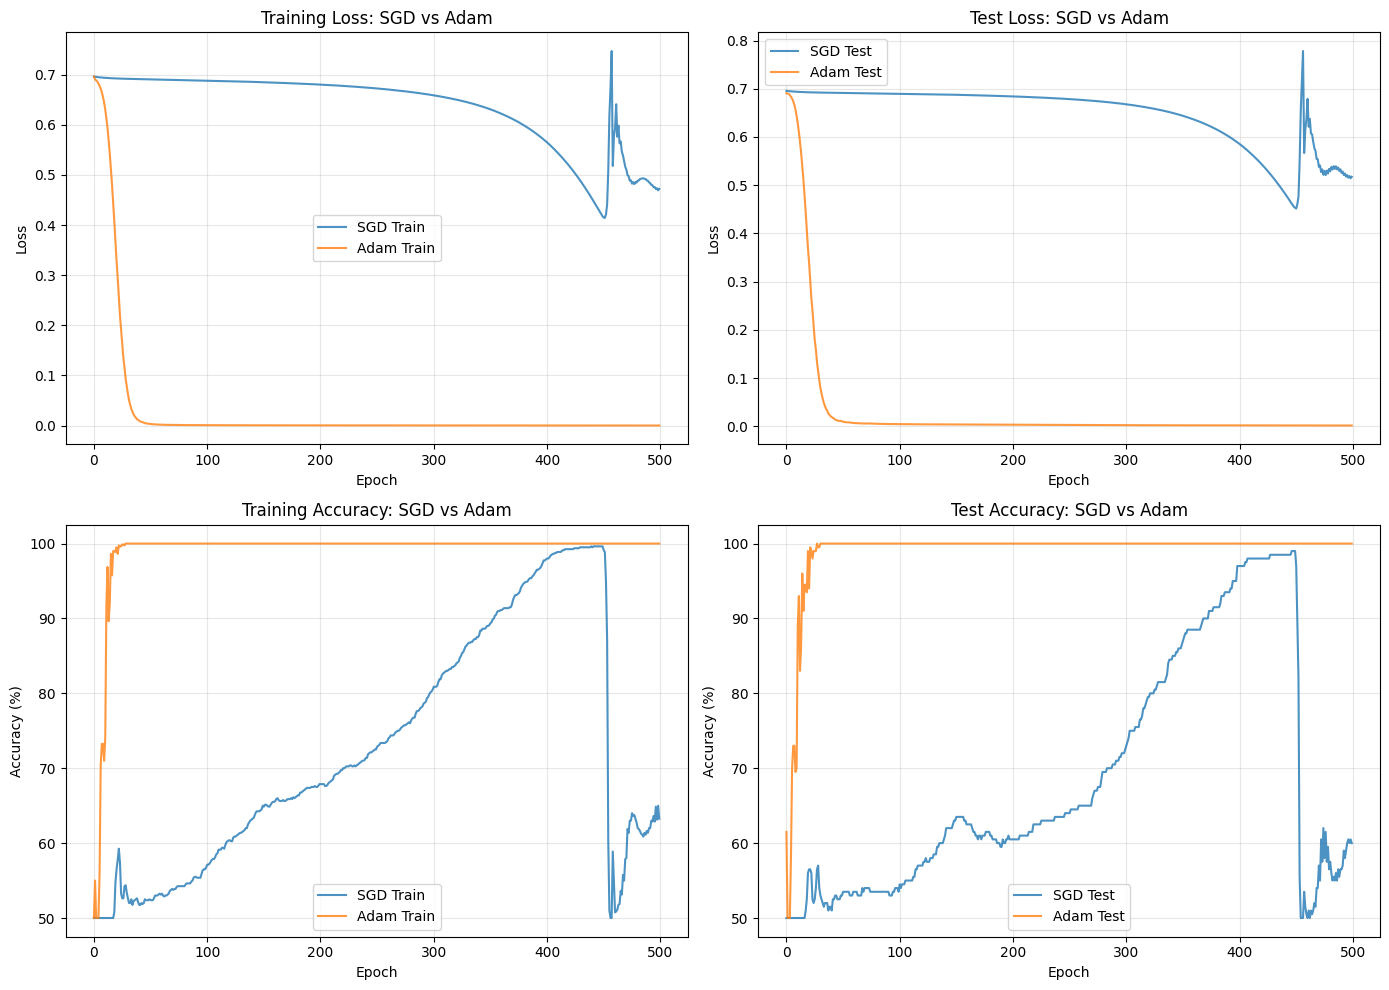


Optimizer Comparison Summary:
SGD - Final Train Acc: 63.25%, Test Acc: 60.00%
Adam - Final Train Acc: 100.00%, Test Acc: 100.00%


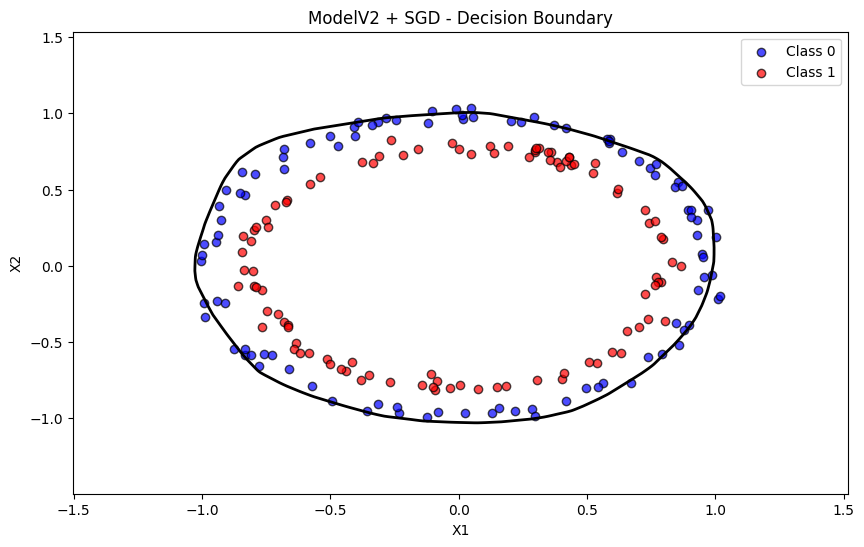

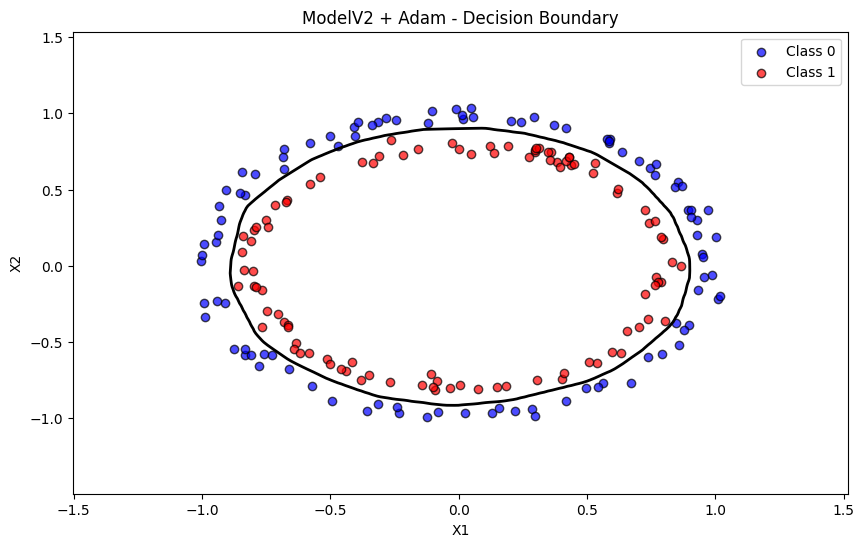

In [22]:
# Compare SGD vs Adam - Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss curves comparison
axes[0, 0].plot(history_sgd['train_losses'], label='SGD Train', alpha=0.8)
axes[0, 0].plot(history_adam['train_losses'], label='Adam Train', alpha=0.8)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training Loss: SGD vs Adam')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history_sgd['test_losses'], label='SGD Test', alpha=0.8)
axes[0, 1].plot(history_adam['test_losses'], label='Adam Test', alpha=0.8)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Test Loss: SGD vs Adam')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Accuracy curves comparison
axes[1, 0].plot(history_sgd['train_accuracies'], label='SGD Train', alpha=0.8)
axes[1, 0].plot(history_adam['train_accuracies'], label='Adam Train', alpha=0.8)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].set_title('Training Accuracy: SGD vs Adam')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(history_sgd['test_accuracies'], label='SGD Test', alpha=0.8)
axes[1, 1].plot(history_adam['test_accuracies'], label='Adam Test', alpha=0.8)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].set_title('Test Accuracy: SGD vs Adam')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
print("\nOptimizer Comparison Summary:")
print(f"SGD - Final Train Acc: {history_sgd['train_accuracies'][-1]:.2f}%, Test Acc: {history_sgd['test_accuracies'][-1]:.2f}%")
print(f"Adam - Final Train Acc: {history_adam['train_accuracies'][-1]:.2f}%, Test Acc: {history_adam['test_accuracies'][-1]:.2f}%")

# Decision boundaries
plot_decision_boundary(model_sgd, X_test, y_test, title="ModelV2 + SGD - Decision Boundary")
plot_decision_boundary(model_adam, X_test, y_test, title="ModelV2 + Adam - Decision Boundary")

## Discussion and Conclusion

In this lab assignment, we built, trained, evaluated, and compared multiple PyTorch neural networks to classify the circles binary classification dataset into class 0 and class 1. Here, class 0 can be classified as points in the outer ring while class 1 as the points in the inner circle. We applied 3 models to train and test: Modelv0, Modelv1 and Modelv2. Modelv1 had 2 inputs, 5 hidden layers and one output. Similary, Model v1 used 2→15→15→1 architecture. Both of them were without any activation function. Hence, both failed to achieve high accuracy on the circle dataset. This is also because they used linear combinations of linear functions to produce linear decision boundaries. But, the circle classification problem requires a non linear decision boundary which cannot be represented using linear models. Therefore, v0 and v1 models failed, regardless of the increase in hidden layers of neurons. 

To overcome this, ModelV2 was trained and tested with the dataset. It used ReLU activation function which successfully learned the decision boundary by introducing non-linearity, allowing to learn complex patterns. The decision boundary of ModelV2 closely matched the required circular structure, therefore, it learned the pattern. Also, the hidden layers were also increased in this model to: 2→64→64→10→1 which also impacted the accuracy.

Testing with SGD and Adam Optimizers, SGD usually takes more time (more epochs) to reach a low error. It makes small, steady updates. Its updates are consistent and less aggressive. Sometimes this helps it settle into a good final solution without overshooting. On the other hand, Adam typically reduces error quicker. You reach good performance in fewer epochs. Adam automatically adjusts how big each step should be for each parameter. If a parameter needs big changes, Adam allows bigger steps. If it needs small refinements, Adam uses smaller steps. Hence, model architecture and optimizer choice significantly impact convergence speed and final performance

All in all, this lab demonstrated the fundamental importance of non-linear activation functions in neural networks. Linear models, regardless of their depth, cannot solve inherently non-linear classification problems like the circles dataset. By introducing ReLU activations, ModelV2 successfully learned the circular decision boundary and achieved high classification accuracy. Additionally, the comparison between SGD and Adam optimizers highlighted how adaptive optimization methods can accelerate training convergence. These insights form the foundation for understanding why deep learning with proper activation functions is powerful for complex pattern recognition tasks.
